# Item ICCs and Information Plots (Estimated from Your Model)

This notebook showcases **new visualization functionality** for estimated items:

- **Item Characteristic Curves (ICCs)** from fitted parameters
- **Empirical ICC overlays** (model vs observed proportions)
- **Item Information Functions (IIFs)** and **Test Information (TIF)**

We use the LSAT7 dataset from the R `mirt` references, but you can use any dataset.

## 0) Install plotting dependency (one-time)

These plots use `matplotlib`. If you don't have it yet, run:

```bash
pip install matplotlib
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from irt import fit

Debug log write OK: /Users/paulius.satkus/Documents/Item Response Theory Python/.cursor/debug.log


## 1) Load data (LSAT7 from mirt)

This dataset comes from the R `mirt` package and is already stored in this repo.

In [2]:
lsat7 = pd.read_csv("../tests/mirt_reference/lsat7_data.csv")
lsat7.shape

(1000, 5)

## 2) Fit a model (Rasch or 2PL)

We'll fit a 2PL model so the ICCs reflect **estimated discriminations and difficulties**.

In [3]:
result = fit(lsat7, model="2pl", estimator="mml_em")
result

FitResult(model='2pl', estimator='mml_em', n_items=5, n_persons=1000, n_iter=43, converged, loglik=-2658.85)

## 3) ICCs from estimated item parameters

This uses the **estimated** `a` and `b` from your fitted model.

- `result.plot_icc()` draws theoretical ICCs.
- You can also select specific items.

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'ICCs for Items 1-3'}, xlabel='Ability ($\\theta$)', ylabel='$P(X=1|\\theta)$'>)

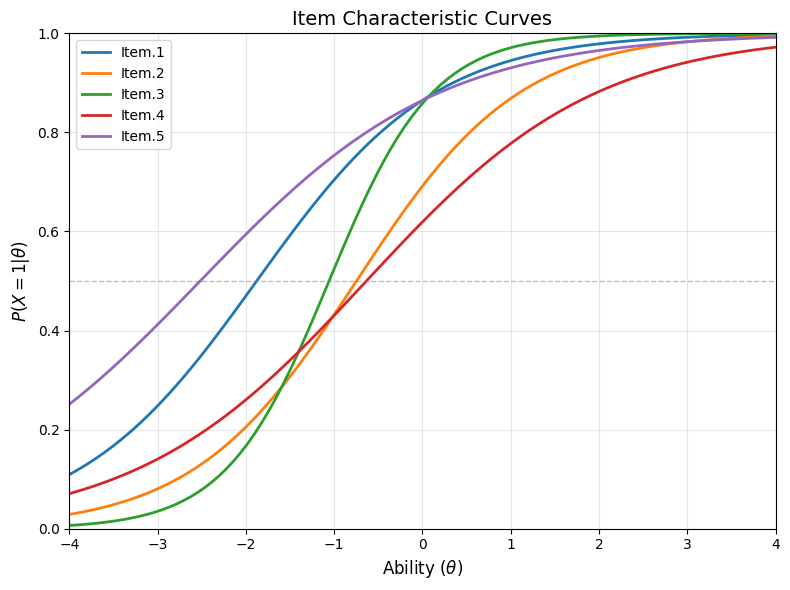

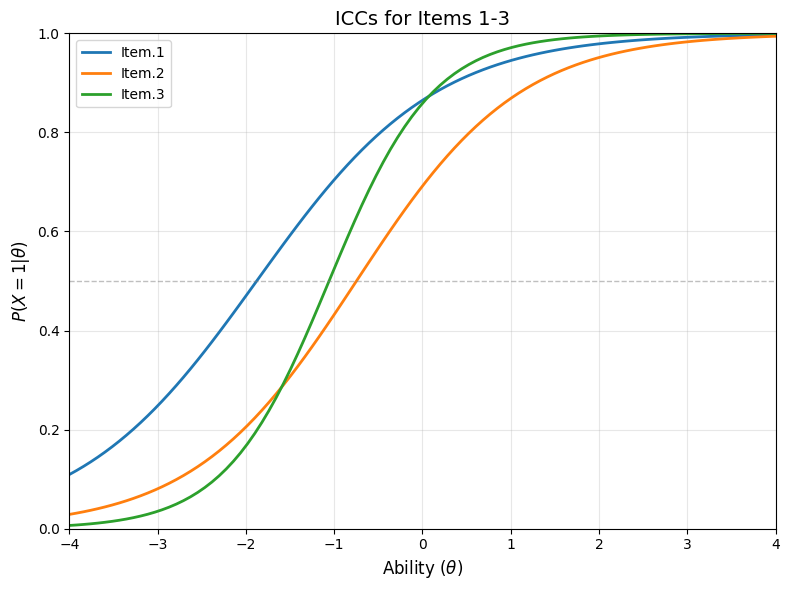

In [4]:
# ICCs for all items
result.plot_icc()

# ICCs for a subset (first 3 items)
result.plot_icc(items=[0, 1, 2], title="ICCs for Items 1-3")

## 4) Empirical ICC overlay (model vs observed)

This is the most important ICC diagnostic:

- The **blue curve** is the model-predicted ICC.
- The **red points** are observed proportions in ability groups.

If the red points track the curve, the item fits well.

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Item.1: ICC with Empirical Fit'}, xlabel='Ability ($\\theta$)', ylabel='$P(X=1|\\theta)$'>)

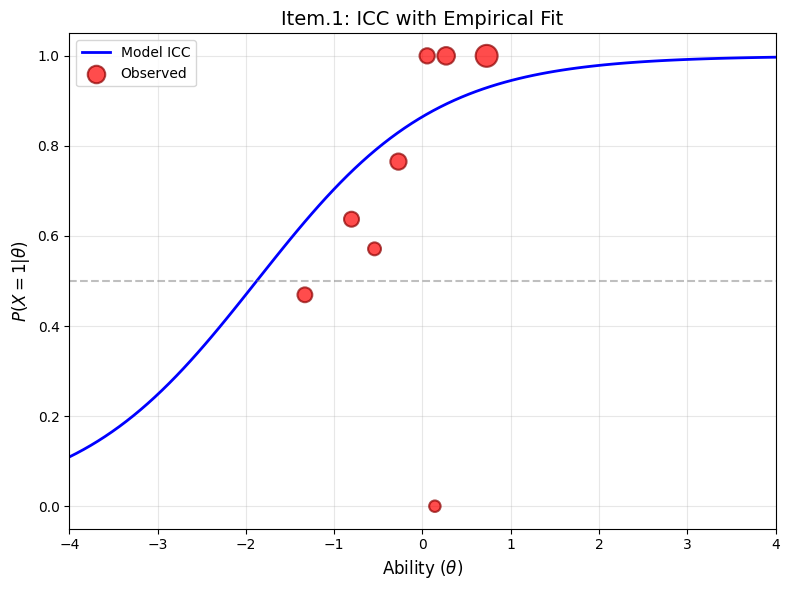

In [5]:
# Empirical ICC for a single item (try changing item_idx)
result.plot_icc_empirical(item_idx=0, n_groups=10)

## 5) Item Information Functions (IIF) and Test Information (TIF)

Information tells you **where** the test is most precise on the ability scale.

- **IIF**: information per item
- **TIF**: sum across all items

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Test Information Function'}, xlabel='Ability ($\\theta$)', ylabel='Information'>)

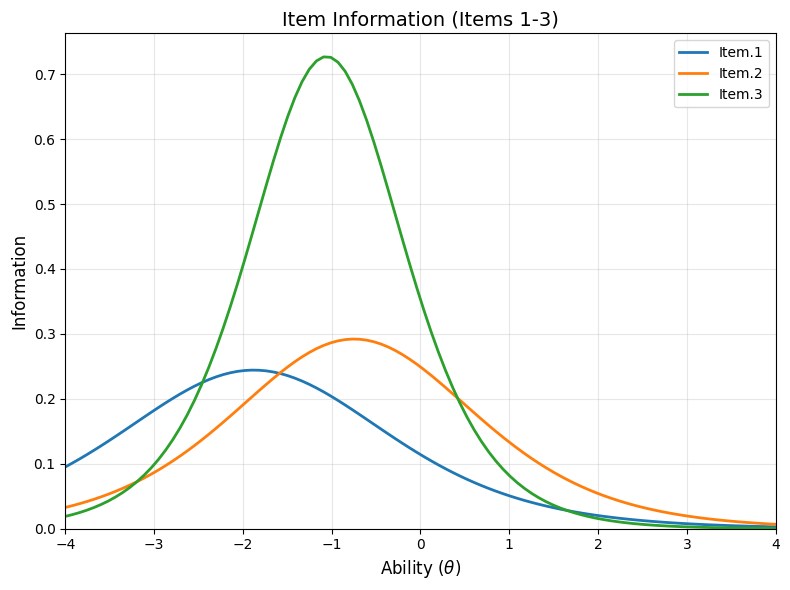

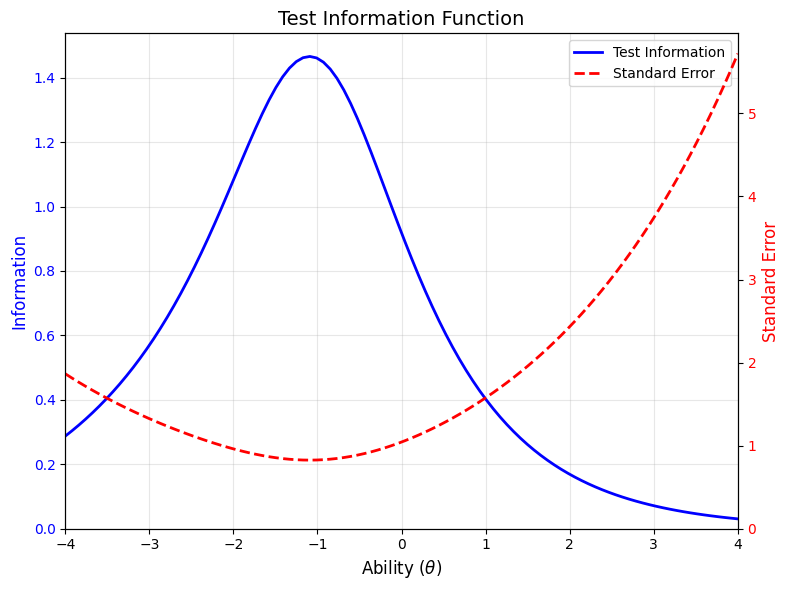

In [6]:
# IIFs for the first 3 items
result.plot_iif(items=[0, 1, 2], title="Item Information (Items 1-3)")

# Test Information for the whole test
result.plot_tif()

## What you learned

- How to plot **estimated ICCs** directly from your fitted model
- How to add **empirical ICC overlays** for item-level fit checks
- How to use **information functions** to see where items and the test are most precise